# 01 - Exploración de Datos (EDA)

**Objetivos:**
- Cargar datos y verificar el reemplazo del valor sentinel `1.79769313486232e+308` por `NaN`
- Análisis univariado: distribución de edad, sexo, grado, IMC
- Análisis bivariado: relación entre factores y el IMC / riesgo de salud mental
- Missingness por columna, ¿qué variables excluir?
- Distribución del target de clasificación (desbalance de clases)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw, get_data_summary
from src.features.engineer import add_all_engineered_features, compute_bmi
from src.config import SENTINEL_VALUE, REGRESSION_FEATURE_COLS, CLASSIFICATION_FEATURE_COLS

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Carga de datos y verificación del sentinel

In [2]:
# Antes de la limpieza: contar celdas con el valor sentinel
df_raw = pd.read_csv('../data/SLV2013_Public_Use.csv')
n_sentinel = (df_raw == SENTINEL_VALUE).sum().sum()
print(f'Shape: {df_raw.shape}')
print(f'Celdas con sentinel (1.797e+308): {n_sentinel}')
print(f'Columnas afectadas: {(df_raw == SENTINEL_VALUE).any().sum()}')

Shape: (1915, 104)
Celdas con sentinel (1.797e+308): 23118
Columnas afectadas: 101


In [3]:
# Después: load_raw reemplaza sentinel - NaN
df = load_raw('../data/SLV2013_Public_Use.csv')
df = add_all_engineered_features(df)

print(f'Shape: {df.shape}')
print(f'NaN totales después de reemplazar sentinel: {df.isnull().sum().sum()}')
print(f'Columnas con NaN: {df.isnull().any().sum()}')
print(f'\nNuevas columnas derivadas: bmi, mental_health_risk, dietary_risk_score,')
print(f'  physical_activity_score, substance_risk_score, social_support_score')

Shape: (1915, 110)
NaN totales después de reemplazar sentinel: 23295
Columnas con NaN: 102

Nuevas columnas derivadas: bmi, mental_health_risk, dietary_risk_score,
  physical_activity_score, substance_risk_score, social_support_score


## 2. Missingness por columna

In [4]:
summary = get_data_summary(df)
print('Top 20 columnas con más datos faltantes:')
summary[summary['null_pct'] > 0][['null_count', 'null_pct', 'nunique']].head(20)

Top 20 columnas con más datos faltantes:


,null_count,null_pct,nunique
qnc2g,1784,0.9316,2
qnc1g,1731,0.9039,2
QN40,1692,0.8836,2
QN47,1582,0.8261,2
QN48,1580,0.8251,2
QN21,1568,0.8188,2
QN45,1565,0.8172,2
QN37,1552,0.8104,2
QN36,1507,0.7869,2
QN18,1465,0.7650,2


## 3. Heatmap de valores faltantes

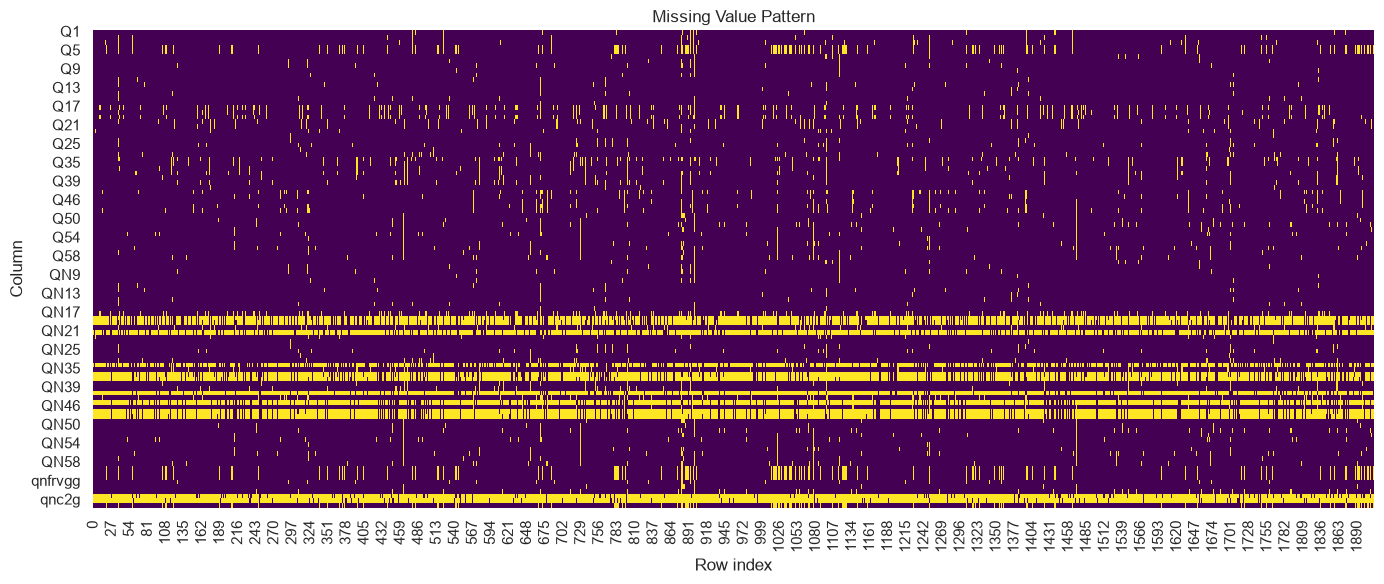

In [5]:
from src.visualization.plots import plot_missing_heatmap
fig = plot_missing_heatmap(df)
plt.show()

## 4. Análisis univariado - Variables demográficas

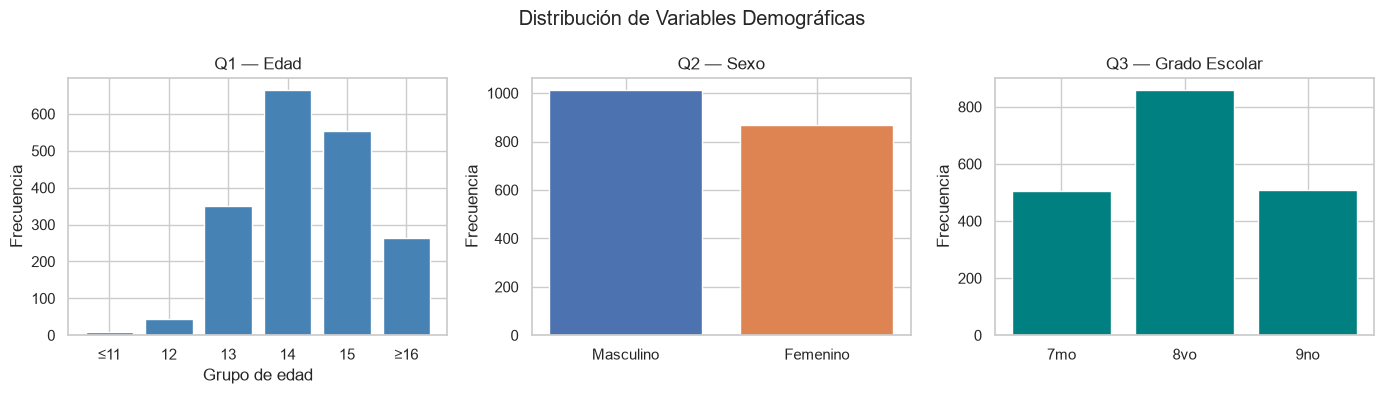

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Q1 - Edad
age_labels = {1: '≤11', 2: '12', 3: '13', 4: '14', 5: '15', 6: '≥16'}
q1_counts = df['Q1'].value_counts().sort_index()
axes[0].bar(q1_counts.index.map(age_labels), q1_counts.values, color='steelblue')
axes[0].set_title('Q1 - Edad')
axes[0].set_xlabel('Grupo de edad')
axes[0].set_ylabel('Frecuencia')

# Q2 - Sexo
sex_labels = {1: 'Masculino', 2: 'Femenino'}
q2_counts = df['Q2'].value_counts().sort_index()
axes[1].bar(q2_counts.index.map(sex_labels), q2_counts.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title('Q2 - Sexo')
axes[1].set_ylabel('Frecuencia')

# Q3 - Grado
grade_labels = {1: '7mo', 2: '8vo', 3: '9no'}
q3_counts = df['Q3'].value_counts().sort_index()
axes[2].bar(q3_counts.index.map(grade_labels), q3_counts.values, color='teal')
axes[2].set_title('Q3 - Grado Escolar')
axes[2].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Demográficas')
plt.tight_layout()
plt.show()

## 5. Análisis univariado - IMC (target de regresión)

IMC - n=1738, media=21.64, mediana=20.71, std=4.14, min=13.8, max=46.8


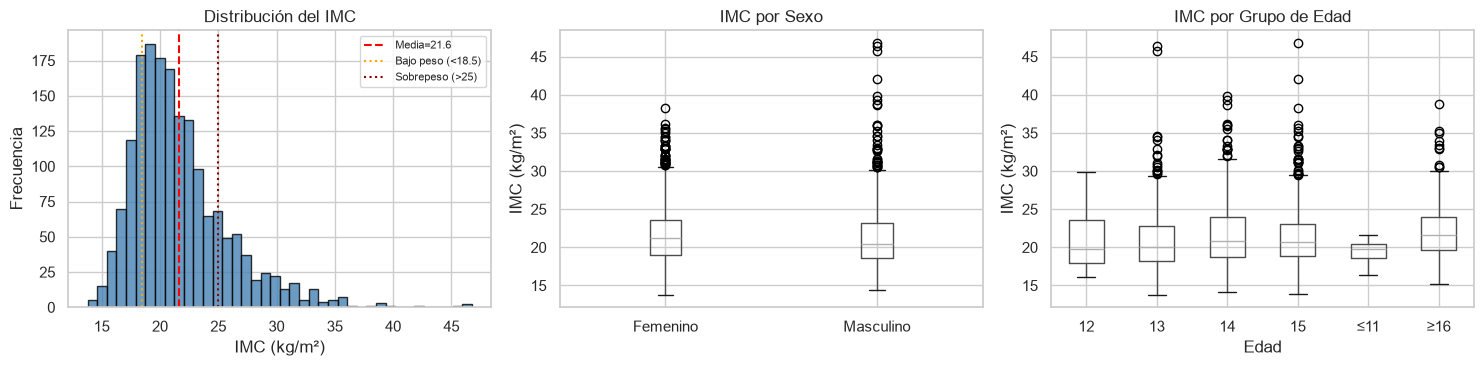

In [7]:
bmi = df['bmi'].dropna()
print(f'IMC - n={len(bmi)}, media={bmi.mean():.2f}, mediana={bmi.median():.2f}, '
      f'std={bmi.std():.2f}, min={bmi.min():.1f}, max={bmi.max():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(bmi, bins=40, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(bmi.mean(), color='red', linestyle='--', label=f'Media={bmi.mean():.1f}')
axes[0].axvline(18.5, color='orange', linestyle=':', label='Bajo peso (<18.5)')
axes[0].axvline(25.0, color='darkred', linestyle=':', label='Sobrepeso (>25)')
axes[0].set_title('Distribución del IMC')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8)

# Boxplot por sexo
bmi_df = df[['bmi', 'Q2']].dropna()
bmi_df['Sexo'] = bmi_df['Q2'].map({1: 'Masculino', 2: 'Femenino'})
bmi_df.boxplot(column='bmi', by='Sexo', ax=axes[1])
axes[1].set_title('IMC por Sexo')
axes[1].set_xlabel('')
axes[1].set_ylabel('IMC (kg/m²)')
plt.sca(axes[1])
plt.title('IMC por Sexo')

# Boxplot por grupo de edad
bmi_age = df[['bmi', 'Q1']].dropna()
bmi_age['Edad'] = bmi_age['Q1'].map({1: '≤11', 2: '12', 3: '13', 4: '14', 5: '15', 6: '≥16'})
order = ['≤11', '12', '13', '14', '15', '≥16']
bmi_age_valid = bmi_age[bmi_age['Edad'].isin(order)]
bmi_age_valid.boxplot(column='bmi', by='Edad', ax=axes[2],
                      positions=range(len(order)))
axes[2].set_title('IMC por Grupo de Edad')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('IMC (kg/m²)')
plt.sca(axes[2])
plt.title('IMC por Grupo de Edad')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. Análisis univariado - Target de clasificación (riesgo de salud mental)

In [ ]:
mhr = df['mental_health_risk'].dropna()
counts = mhr.value_counts().sort_index()
total = len(mhr)

print('mental_health_risk - definición (riesgo grave / suicidalidad):')
print('  1 = en riesgo: QN24 (ideación) O QN25 (plan) O QN26 (intento de suicidio)')
print('  0 = sin señal de suicidalidad')
print(f'\n  n total: {total}')
print(f'  Clase 0 (sin riesgo): {counts.get(0, 0):>4} ({100*counts.get(0,0)/total:.1f}%)')
print(f'  Clase 1 (en riesgo):  {counts.get(1, 0):>4} ({100*counts.get(1,0)/total:.1f}%)')
print(f'  Ratio desbalance:     {counts.get(0,1)/counts.get(1,1):.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución global
axes[0].bar(['Sin riesgo (0)', 'En riesgo (1)'], counts.values,
            color=['#4C72B0', '#C44E52'], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({100*v/total:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Prevalencia de Riesgo de Salud Mental')
axes[0].set_ylabel('Número de estudiantes')

# Prevalencia por sexo
risk_sex = df[['mental_health_risk', 'Q2']].dropna()
risk_sex['Sexo'] = risk_sex['Q2'].map({1: 'Masculino', 2: 'Femenino'})
prevalence = risk_sex.groupby('Sexo')['mental_health_risk'].mean() * 100
prevalence.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black', rot=0)
axes[1].set_title('Prevalencia de Riesgo por Sexo (%)')
axes[1].set_ylabel('% en riesgo')
axes[1].set_ylim(0, 50)
for i, v in enumerate(prevalence):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## 7. Análisis bivariado - IMC vs factores de alimentación y actividad física

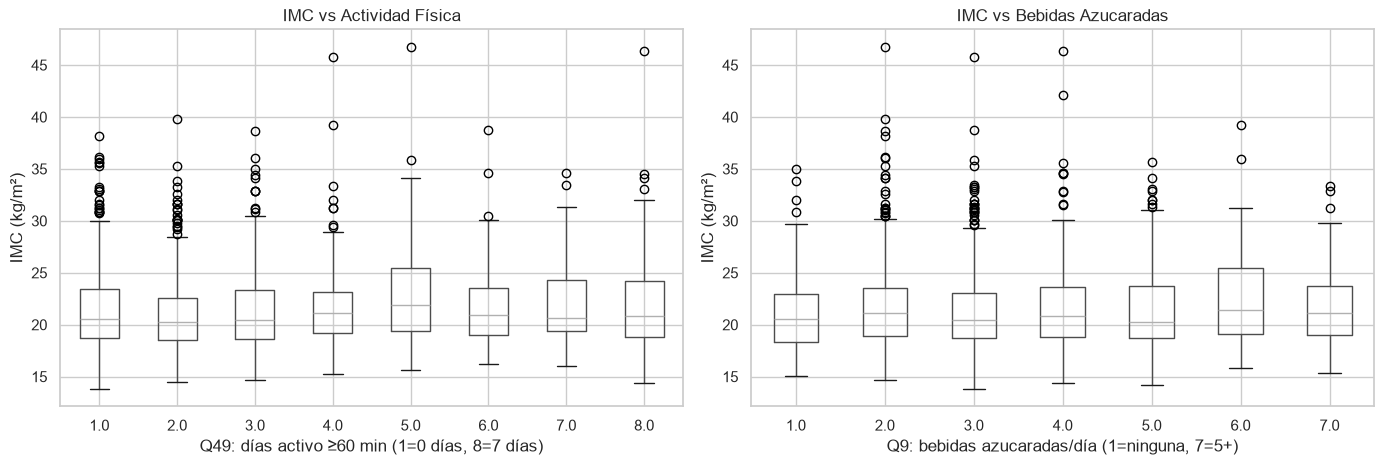

In [9]:
# Boxplot de IMC por nivel de actividad física (Q49: días activo ≥60 min)
# y por consumo de bebidas azucaradas (Q9)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bmi_act = df[['bmi', 'Q49']].dropna()
bmi_act.boxplot(column='bmi', by='Q49', ax=axes[0])
axes[0].set_title('IMC según días de actividad física (Q49)')
axes[0].set_xlabel('Q49: días activo ≥60 min (1=0 días, 8=7 días)')
axes[0].set_ylabel('IMC (kg/m²)')
plt.sca(axes[0]); plt.title('IMC vs Actividad Física')

bmi_soda = df[['bmi', 'Q9']].dropna()
bmi_soda.boxplot(column='bmi', by='Q9', ax=axes[1])
axes[1].set_title('IMC según consumo de bebidas azucaradas (Q9)')
axes[1].set_xlabel('Q9: bebidas azucaradas/día (1=ninguna, 7=5+)')
axes[1].set_ylabel('IMC (kg/m²)')
plt.sca(axes[1]); plt.title('IMC vs Bebidas Azucaradas')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Análisis bivariado - Riesgo mental vs factores de riesgo y protección

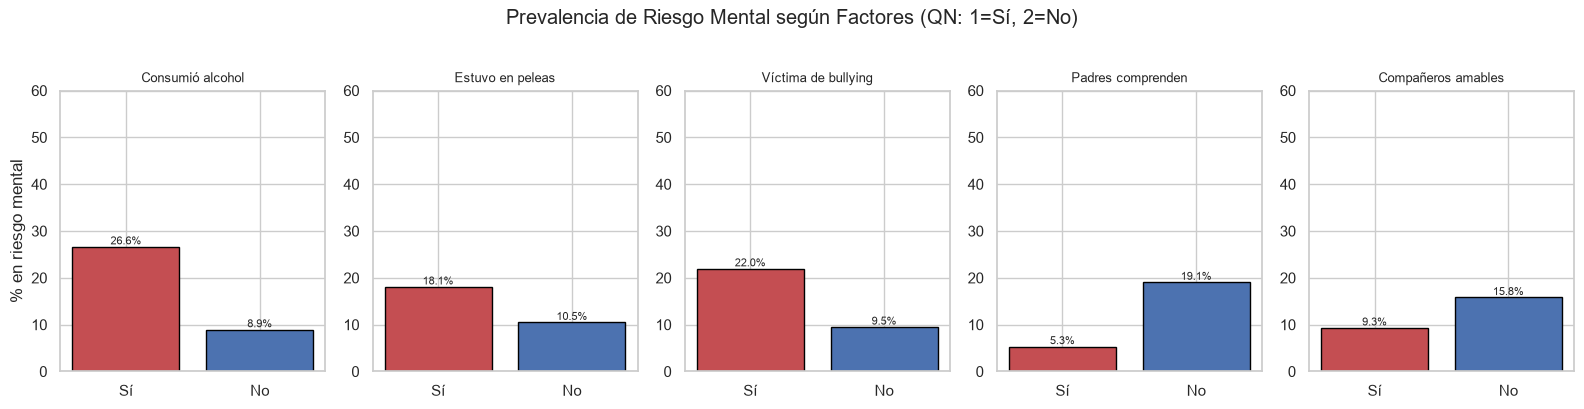

In [10]:
# Prevalencia de riesgo mental según factores clave (columnas QN: 1=Sí, 2=No)
factors = {
    'QN35': 'Consumió alcohol',
    'QN16': 'Estuvo en peleas',
    'QN20': 'Víctima de bullying',
    'QN56': 'Padres comprenden',
    'QN54': 'Compañeros amables',
}

fig, axes = plt.subplots(1, len(factors), figsize=(16, 4))
for ax, (col, label) in zip(axes, factors.items()):
    if col not in df.columns:
        continue
    tmp = df[[col, 'mental_health_risk']].dropna()
    # 1=Sí, 2=No en escala OMS
    prev = tmp.groupby(col)['mental_health_risk'].mean() * 100
    bar_labels = {1: 'Sí', 2: 'No'}
    colors = ['#C44E52', '#4C72B0']
    ax.bar([bar_labels.get(k, k) for k in prev.index], prev.values,
           color=colors[:len(prev)], edgecolor='black')
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('% en riesgo mental' if ax == axes[0] else '')
    ax.set_ylim(0, 60)
    for i, v in enumerate(prev.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)

plt.suptitle('Prevalencia de Riesgo Mental según Factores (QN: 1=Sí, 2=No)', y=1.02)
plt.tight_layout()
plt.show()